In [ ]:

import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_log_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv("/kaggle/input/output/output.csv")
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [ ]:

print("Dataset Info:")
print(df.info())

print("\nSummary statistics for numerical columns:")
print(df.describe())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nData types of each column:")
print(df.dtypes)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5421 entries, 0 to 5420
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      5421 non-null   object 
 1   rating    5421 non-null   object 
 2   genre     5421 non-null   object 
 3   year      5421 non-null   int64  
 4   released  5421 non-null   object 
 5   score     5421 non-null   float64
 6   votes     5421 non-null   float64
 7   director  5421 non-null   object 
 8   writer    5421 non-null   object 
 9   star      5421 non-null   object 
 10  country   5421 non-null   object 
 11  budget    5421 non-null   float64
 12  gross     5421 non-null   float64
 13  company   5421 non-null   object 
 14  runtime   5421 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 635.4+ KB
None

Summary statistics for numerical columns:
              year        score         votes        budget         gross  \
count  5421.000000  5421.00

In [ ]:

def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    msle = mean_squared_log_error(y_true, y_pred)
    mape = np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100
    return r2, mse, msle, mape


In [ ]:

X, y = prepare_features(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
train_predictions_lr = lr_model.predict(X_train)
test_predictions_lr = lr_model.predict(X_test)

train_r2_lr, train_mse_lr, train_msle_lr, train_mape_lr = calculate_metrics(y_train, train_predictions_lr)
test_r2_lr, test_mse_lr, test_msle_lr, test_mape_lr = calculate_metrics(y_test, test_predictions_lr)

print(f"\nLinear Regression Metrics:")
print(f"Train R2: {train_r2_lr:.4f}, MSE: {train_mse_lr:.4f}, MSLE: {train_msle_lr:.4f}, MAPE: {train_mape_lr:.2f}%")
print(f"Test R2: {test_r2_lr:.4f}, MSE: {test_mse_lr:.4f}, MSLE: {test_msle_lr:.4f}, MAPE: {test_mape_lr:.2f}%")


Linear Regression Metrics:
Train R2: 0.6181, MSE: 1.3395, MSLE: 0.0053, MAPE: 1111.15%
Test R2: 0.6520, MSE: 1.3127, MSLE: 0.0051, MAPE: 350.47%


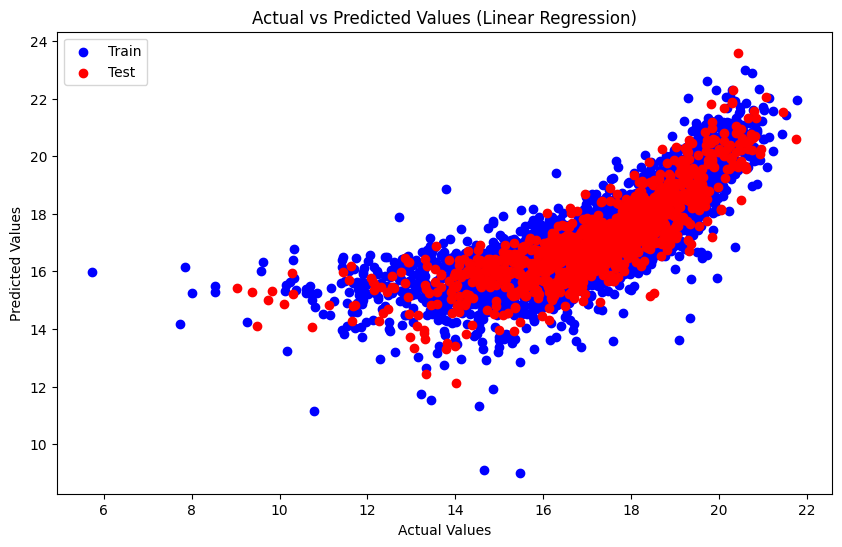

In [ ]:

plt.figure(figsize=(10, 6))
plt.scatter(y_train, train_predictions_lr, color="blue", label="Train")
plt.scatter(y_test, test_predictions_lr, color="red", label="Test")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()


In [ ]:

# Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)
train_predictions_dt = dt_model.predict(X_train)
test_predictions_dt = dt_model.predict(X_test)

train_r2_dt, train_mse_dt, train_msle_dt, train_mape_dt = calculate_metrics(y_train, train_predictions_dt)
test_r2_dt, test_mse_dt, test_msle_dt, test_mape_dt = calculate_metrics(y_test, test_predictions_dt)

print(f"\nDecision Tree Regressor Metrics:")
print(f"Train R2: {train_r2_dt:.4f}, MSE: {train_mse_dt:.4f}, MSLE: {train_msle_dt:.4f}, MAPE: {train_mape_dt:.2f}%")
print(f"Test R2: {test_r2_dt:.4f}, MSE: {test_mse_dt:.4f}, MSLE: {test_msle_dt:.4f}, MAPE: {test_mape_dt:.2f}%")



Decision Tree Regressor Metrics:
Train R2: 0.8310, MSE: 0.5927, MSLE: 0.0024, MAPE: 138.11%
Test R2: 0.5994, MSE: 1.5114, MSLE: 0.0059, MAPE: 326.26%


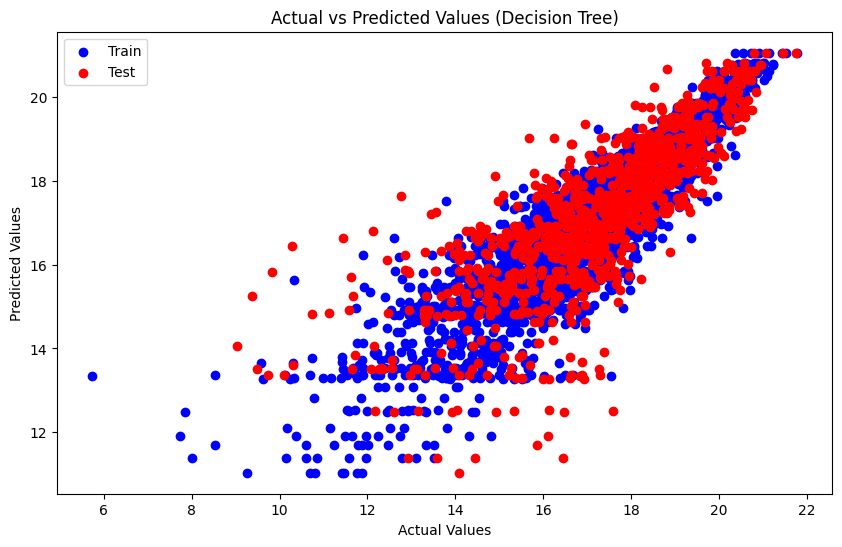

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_train, train_predictions_dt, color="blue", label="Train")
plt.scatter(y_test, test_predictions_dt, color="red", label="Test")
plt.title("Actual vs Predicted Values (Decision Tree)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()


In [ ]:

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train, y_train)
train_predictions_rf = rf_model.predict(X_train)
test_predictions_rf = rf_model.predict(X_test)

train_r2_rf, train_mse_rf, train_msle_rf, train_mape_rf = calculate_metrics(y_train, train_predictions_rf)
test_r2_rf, test_mse_rf, test_msle_rf, test_mape_rf = calculate_metrics(y_test, test_predictions_rf)

print(f"\nRandom Forest Regressor Metrics:")
print(f"Train R2: {train_r2_rf:.4f}, MSE: {train_mse_rf:.4f}, MSLE: {train_msle_rf:.4f}, MAPE: {train_mape_rf:.2f}%")
print(f"Test R2: {test_r2_rf:.4f}, MSE: {test_mse_rf:.4f}, MSLE: {test_msle_rf:.4f}, MAPE: {test_mape_rf:.2f}%")


Random Forest Regressor Metrics:
Train R2: 0.8475, MSE: 0.5350, MSLE: 0.0022, MAPE: 169.86%
Test R2: 0.7235, MSE: 1.0431, MSLE: 0.0041, MAPE: 203.30%


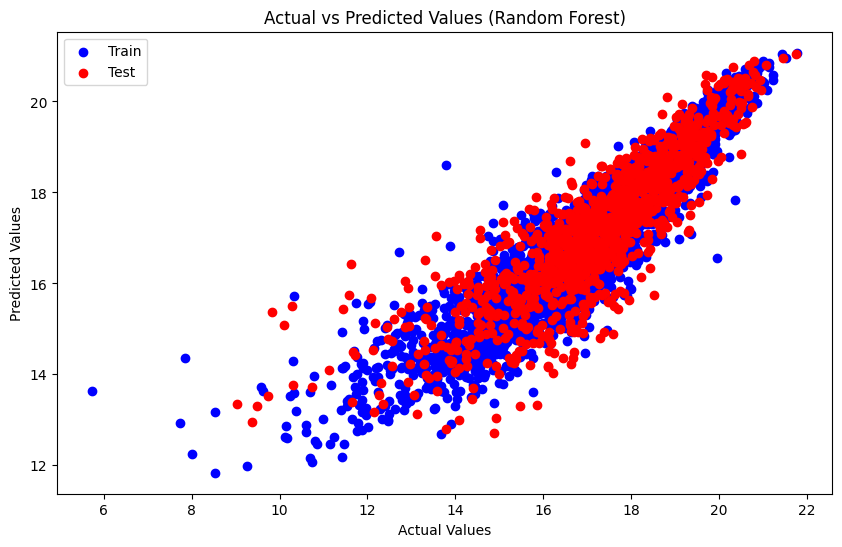

In [ ]:

# Visualizing Actual vs Predicted Values (for Random Forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_train, train_predictions_rf, color="blue", label="Train")
plt.scatter(y_test, test_predictions_rf, color="red", label="Test")
plt.title("Actual vs Predicted Values (Random Forest)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()